<a href="https://colab.research.google.com/github/iiiyahiya111/Project/blob/main/ERA5_Land_2001_2025_Full_QC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ERA5-Land 2001–2025 Full Dataset QC

This notebook reads the raw ERA5-Land ZIP from Google Drive and performs **read-only quality control**.

**Raw ZIP:** `ERA5_Land_Gobindaganj_2001_2025_raw.zip`

Expected hourly coverage: **2001-01-01 00:00 UTC → 2025-12-31 23:00 UTC = 219,144 hours**.

The raw files are not modified.

In [16]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import os
import zipfile
from pathlib import Path

ZIP_PATH = '/content/drive/MyDrive/ERA5_Land_Gobindaganj_2001_2025_raw.zip'
EXTRACT_DIR = '/content/era5_land_raw'

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f'ZIP not found: {ZIP_PATH}')

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)

print('Extraction completed.')
print('Extracted files:')
for p in sorted(Path(EXTRACT_DIR).rglob('*')):
    if p.is_file():
        print(p)

Extraction completed.
Extracted files:
/content/era5_land_raw/ERA5_Land_Gobindaganj_2001_2025_raw/reanalysis-era5-land-timeseries-sfc-2m-temperaturex1jkn6o0.csv
/content/era5_land_raw/ERA5_Land_Gobindaganj_2001_2025_raw/reanalysis-era5-land-timeseries-sfc-pressure-precipitationq4gbdlrm.csv
/content/era5_land_raw/ERA5_Land_Gobindaganj_2001_2025_raw/reanalysis-era5-land-timeseries-sfc-windfjnn8ksw.csv


In [18]:
import glob
import os

csv_files = sorted(glob.glob(f'{EXTRACT_DIR}/**/*.csv', recursive=True))

print(f'Total CSV files found: {len(csv_files)}\n')
for f in csv_files:
    print(os.path.basename(f))

Total CSV files found: 3

reanalysis-era5-land-timeseries-sfc-2m-temperaturex1jkn6o0.csv
reanalysis-era5-land-timeseries-sfc-pressure-precipitationq4gbdlrm.csv
reanalysis-era5-land-timeseries-sfc-windfjnn8ksw.csv


In [19]:
import pandas as pd

for f in csv_files:
    df_test = pd.read_csv(f, nrows=5)
    print('\n' + '=' * 80)
    print('FILE:', os.path.basename(f))
    print('COLUMNS:', list(df_test.columns))
    print('=' * 80)


FILE: reanalysis-era5-land-timeseries-sfc-2m-temperaturex1jkn6o0.csv
COLUMNS: ['valid_time', 'd2m', 't2m', 'latitude', 'longitude']

FILE: reanalysis-era5-land-timeseries-sfc-pressure-precipitationq4gbdlrm.csv
COLUMNS: ['valid_time', 'tp', 'latitude', 'longitude']

FILE: reanalysis-era5-land-timeseries-sfc-windfjnn8ksw.csv
COLUMNS: ['valid_time', 'u10', 'v10', 'latitude', 'longitude']


In [20]:
temp_file = None
precip_file = None
wind_file = None

for f in csv_files:
    cols = {c.lower() for c in pd.read_csv(f, nrows=1).columns}

    if {'t2m', 'd2m'}.issubset(cols):
        temp_file = f
    elif 'tp' in cols:
        precip_file = f
    elif {'u10', 'v10'}.issubset(cols):
        wind_file = f

print('Temperature/Dewpoint file:', temp_file)
print('Precipitation file:', precip_file)
print('Wind file:', wind_file)

if not all([temp_file, precip_file, wind_file]):
    raise RuntimeError('Could not identify all three expected ERA5-Land CSV files.')

Temperature/Dewpoint file: /content/era5_land_raw/ERA5_Land_Gobindaganj_2001_2025_raw/reanalysis-era5-land-timeseries-sfc-2m-temperaturex1jkn6o0.csv
Precipitation file: /content/era5_land_raw/ERA5_Land_Gobindaganj_2001_2025_raw/reanalysis-era5-land-timeseries-sfc-pressure-precipitationq4gbdlrm.csv
Wind file: /content/era5_land_raw/ERA5_Land_Gobindaganj_2001_2025_raw/reanalysis-era5-land-timeseries-sfc-windfjnn8ksw.csv


In [21]:
temp_df = pd.read_csv(temp_file)
precip_df = pd.read_csv(precip_file)
wind_df = pd.read_csv(wind_file)

print('Temperature/Dewpoint shape:', temp_df.shape)
print('Precipitation shape      :', precip_df.shape)
print('Wind shape               :', wind_df.shape)

Temperature/Dewpoint shape: (219144, 5)
Precipitation shape      : (219144, 4)
Wind shape               : (219144, 5)


In [22]:
for name, df in {
    'Temperature/Dewpoint': temp_df,
    'Precipitation': precip_df,
    'Wind': wind_df,
}.items():
    dt = pd.to_datetime(df['valid_time'], utc=True)
    print(f'\n{name}')
    print('Start:', dt.min())
    print('End  :', dt.max())
    print('Rows :', len(df))


Temperature/Dewpoint
Start: 2001-01-01 00:00:00+00:00
End  : 2025-12-31 23:00:00+00:00
Rows : 219144

Precipitation
Start: 2001-01-01 00:00:00+00:00
End  : 2025-12-31 23:00:00+00:00
Rows : 219144

Wind
Start: 2001-01-01 00:00:00+00:00
End  : 2025-12-31 23:00:00+00:00
Rows : 219144


In [23]:
start = pd.Timestamp('2001-01-01 00:00:00', tz='UTC')
end = pd.Timestamp('2025-12-31 23:00:00', tz='UTC')
expected_hours = int((end - start).total_seconds() / 3600) + 1

print('Expected hourly rows:', expected_hours)

for name, df in {
    'Temperature/Dewpoint': temp_df,
    'Precipitation': precip_df,
    'Wind': wind_df,
}.items():
    print(
        f'{name:22s} Actual={len(df):6d} | '
        f'Expected={expected_hours:6d} | '
        f'OK={len(df) == expected_hours}'
    )

Expected hourly rows: 219144
Temperature/Dewpoint   Actual=219144 | Expected=219144 | OK=True
Precipitation          Actual=219144 | Expected=219144 | OK=True
Wind                   Actual=219144 | Expected=219144 | OK=True


In [24]:
for name, df in {
    'Temperature/Dewpoint': temp_df,
    'Precipitation': precip_df,
    'Wind': wind_df,
}.items():
    dt = pd.to_datetime(df['valid_time'], utc=True)
    print(f'{name:22s} Duplicate timestamps = {dt.duplicated().sum()}')

Temperature/Dewpoint   Duplicate timestamps = 0
Precipitation          Duplicate timestamps = 0
Wind                   Duplicate timestamps = 0


In [25]:
for name, df in {
    'Temperature/Dewpoint': temp_df,
    'Precipitation': precip_df,
    'Wind': wind_df,
}.items():
    dt = pd.to_datetime(df['valid_time'], utc=True).sort_values()
    expected_index = pd.date_range(dt.min(), dt.max(), freq='1h', tz='UTC')
    missing = expected_index.difference(dt)

    print(f'\n{name}')
    print('Missing hourly timestamps:', len(missing))
    if len(missing):
        print('First missing timestamps:')
        print(missing[:10])


Temperature/Dewpoint
Missing hourly timestamps: 0

Precipitation
Missing hourly timestamps: 0

Wind
Missing hourly timestamps: 0


In [26]:
for name, df in {
    'Temperature/Dewpoint': temp_df,
    'Precipitation': precip_df,
    'Wind': wind_df,
}.items():
    print(f'\n{name}')
    print('Latitude unique :', df['latitude'].nunique())
    print('Longitude unique:', df['longitude'].nunique())
    print('Latitude values :', df['latitude'].unique())
    print('Longitude values:', df['longitude'].unique())


Temperature/Dewpoint
Latitude unique : 1
Longitude unique: 1
Latitude values : [25.2]
Longitude values: [89.3]

Precipitation
Latitude unique : 1
Longitude unique: 1
Latitude values : [25.2]
Longitude values: [89.3]

Wind
Latitude unique : 1
Longitude unique: 1
Latitude values : [25.2]
Longitude values: [89.3]


In [27]:
for name, df in {
    'Temperature/Dewpoint': temp_df,
    'Precipitation': precip_df,
    'Wind': wind_df,
}.items():
    print(f'\n{name}')
    display(df.isna().sum().to_frame('missing_count'))


Temperature/Dewpoint


,missing_count
valid_time,0
d2m,0
t2m,0
latitude,0
longitude,0



Precipitation


,missing_count
valid_time,0
tp,0
latitude,0
longitude,0



Wind


,missing_count
valid_time,0
u10,0
v10,0
latitude,0
longitude,0


In [28]:
checks = {
    'Temperature (t2m)': temp_df['t2m'],
    'Dewpoint (d2m)': temp_df['d2m'],
    'Precipitation (tp)': precip_df['tp'],
    'U10': wind_df['u10'],
    'V10': wind_df['v10'],
}

for name, series in checks.items():
    print(f'\n{name}')
    print('Min :', series.min())
    print('Max :', series.max())
    print('Mean:', series.mean())


Temperature (t2m)
Min : 279.78506
Max : 313.9129
Mean: 297.8174565897766

Dewpoint (d2m)
Min : 272.1903
Max : 302.81677
Mean: 293.0197820571861

Precipitation (tp)
Min : -3.830064e-08
Max : 0.03442104
Mean: 0.0002407690304391832

U10
Min : -11.862137
Max : 7.52269
Mean: -0.5218241124557326

V10
Min : -9.396011
Max : 9.663422
Mean: 0.2253917193818288


In [29]:
negative_tp = precip_df.loc[precip_df['tp'] < 0, 'tp']

print('Negative precipitation records:', len(negative_tp))
if len(negative_tp):
    print('Minimum negative value:', negative_tp.min())
    print('Maximum negative value:', negative_tp.max())
    print('\nNote: raw data are not modified. Tiny negative floating-point artifacts, if present, will be handled only in the processed layer with an explicit rule.')

Negative precipitation records: 3315
Minimum negative value: -3.830064e-08
Maximum negative value: -5.684342e-14

Note: raw data are not modified. Tiny negative floating-point artifacts, if present, will be handled only in the processed layer with an explicit rule.


In [30]:
qc_summary = []

for name, df in {
    'temperature_dewpoint': temp_df,
    'precipitation': precip_df,
    'wind': wind_df,
}.items():
    dt = pd.to_datetime(df['valid_time'], utc=True).sort_values()
    expected_index = pd.date_range(dt.min(), dt.max(), freq='1h', tz='UTC')

    qc_summary.append({
        'dataset': name,
        'rows': len(df),
        'start': str(dt.min()),
        'end': str(dt.max()),
        'expected_rows_for_own_range': len(expected_index),
        'row_count_ok': len(df) == len(expected_index),
        'duplicate_timestamps': int(dt.duplicated().sum()),
        'missing_hours': int(len(expected_index.difference(dt))),
        'missing_values': int(df.isna().sum().sum()),
        'latitude_unique': int(df['latitude'].nunique()),
        'longitude_unique': int(df['longitude'].nunique()),
    })

qc_df = pd.DataFrame(qc_summary)
display(qc_df)

,dataset,rows,start,end,expected_rows_for_own_range,row_count_ok,duplicate_timestamps,missing_hours,missing_values,latitude_unique,longitude_unique
0,temperature_dewpoint,219144,2001-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00,219144,True,0,0,0,1,1
1,precipitation,219144,2001-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00,219144,True,0,0,0,1,1
2,wind,219144,2001-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00,219144,True,0,0,0,1,1


# **Merge the three datasets**

In [31]:
import pandas as pd
import numpy as np

# Keep only required columns
temp = temp_df[
    ["valid_time", "latitude", "longitude", "t2m", "d2m"]
].copy()

rain = precip_df[
    ["valid_time", "latitude", "longitude", "tp"]
].copy()

wind = wind_df[
    ["valid_time", "latitude", "longitude", "u10", "v10"]
].copy()

# Merge using timestamp + coordinates
merged_df = (
    temp
    .merge(
        rain,
        on=["valid_time", "latitude", "longitude"],
        how="inner",
        validate="one_to_one"
    )
    .merge(
        wind,
        on=["valid_time", "latitude", "longitude"],
        how="inner",
        validate="one_to_one"
    )
)

print("Merged shape:", merged_df.shape)
print("\nColumns:")
print(list(merged_df.columns))

Merged shape: (219144, 8)

Columns:
['valid_time', 'latitude', 'longitude', 't2m', 'd2m', 'tp', 'u10', 'v10']


# **Convert temperature and calculate RH**

In [32]:
# Temperature and dew point: Kelvin → Celsius
merged_df["T_C"] = merged_df["t2m"] - 273.15
merged_df["Td_C"] = merged_df["d2m"] - 273.15

# Magnus-type RH calculation
a = 17.625
b = 243.04

gamma_T = (a * merged_df["Td_C"]) / (b + merged_df["Td_C"])
gamma_RH = (a * merged_df["T_C"]) / (b + merged_df["T_C"])

merged_df["RH_pct"] = (
    100 * np.exp(gamma_T - gamma_RH)
)

# Bound derived RH to physical range
merged_df["RH_pct"] = merged_df["RH_pct"].clip(0, 100)

# **Convert rainfall and calculate wind speed**

In [33]:
# ERA5-Land precipitation: metres → mm/hour
merged_df["Rain_mm_h"] = merged_df["tp"] * 1000

# Tiny negative floating-point artifacts → 0
merged_df.loc[merged_df["Rain_mm_h"] < 0, "Rain_mm_h"] = 0

# Wind speed from u10 and v10
merged_df["wind_ms"] = np.sqrt(
    merged_df["u10"]**2 + merged_df["v10"]**2
)

# **UTC and Bangladesh Standard Time**

In [34]:
merged_df["datetime_utc"] = pd.to_datetime(
    merged_df["valid_time"],
    utc=True
)

merged_df["datetime_bst"] = (
    merged_df["datetime_utc"]
    .dt.tz_convert("Asia/Dhaka")
)

# **Create final processed dataset**

In [35]:
processed_df = merged_df[
    [
        "datetime_utc",
        "datetime_bst",
        "latitude",
        "longitude",
        "T_C",
        "RH_pct",
        "Rain_mm_h",
        "wind_ms",
        "valid_time"
    ]
].copy()

processed_df = processed_df.sort_values(
    "datetime_utc"
).reset_index(drop=True)

print(processed_df.shape)
display(processed_df.head())
display(processed_df.tail())

(219144, 9)


,datetime_utc,datetime_bst,latitude,longitude,T_C,RH_pct,Rain_mm_h,wind_ms,valid_time
0,2001-01-01 00:00:00+00:00,2001-01-01 06:00:00+06:00,25.2,89.3,12.45230,89.237445,0.000852,1.575941,2001-01-01 00:00:00
1,2001-01-01 01:00:00+00:00,2001-01-01 07:00:00+06:00,25.2,89.3,12.14858,90.169035,0.000000,1.586782,2001-01-01 01:00:00
2,2001-01-01 02:00:00+00:00,2001-01-01 08:00:00+06:00,25.2,89.3,14.48885,83.876529,0.000000,0.834480,2001-01-01 02:00:00
3,2001-01-01 03:00:00+00:00,2001-01-01 09:00:00+06:00,25.2,89.3,17.56765,70.534087,0.000000,0.676846,2001-01-01 03:00:00
4,2001-01-01 04:00:00+00:00,2001-01-01 10:00:00+06:00,25.2,89.3,19.48360,64.125701,0.000000,1.191457,2001-01-01 04:00:00


,datetime_utc,datetime_bst,latitude,longitude,T_C,RH_pct,Rain_mm_h,wind_ms,valid_time
219139,2025-12-31 19:00:00+00:00,2026-01-01 01:00:00+06:00,25.2,89.3,12.57190,91.625560,0.000000,2.024737,2025-12-31 19:00:00
219140,2025-12-31 20:00:00+00:00,2026-01-01 02:00:00+06:00,25.2,89.3,12.21993,92.598256,0.000000,2.000171,2025-12-31 20:00:00
219141,2025-12-31 21:00:00+00:00,2026-01-01 03:00:00+06:00,25.2,89.3,11.90164,93.357000,0.000000,2.015917,2025-12-31 21:00:00
219142,2025-12-31 22:00:00+00:00,2026-01-01 04:00:00+06:00,25.2,89.3,11.65798,93.985206,0.000000,2.007991,2025-12-31 22:00:00
219143,2025-12-31 23:00:00+00:00,2026-01-01 05:00:00+06:00,25.2,89.3,11.39950,94.542606,0.000007,1.998718,2025-12-31 23:00:00


# **Final processed QC**

In [36]:
print("Rows:", len(processed_df))
print("Duplicate timestamps:", processed_df["datetime_utc"].duplicated().sum())
print("Missing values:", processed_df.isna().sum().sum())

print("\nDate range:")
print("Start:", processed_df["datetime_utc"].min())
print("End  :", processed_df["datetime_utc"].max())

print("\nPhysical checks:")
print("T range:", processed_df["T_C"].min(), "to", processed_df["T_C"].max())
print("RH range:", processed_df["RH_pct"].min(), "to", processed_df["RH_pct"].max())
print("Rain min:", processed_df["Rain_mm_h"].min())
print("Wind min:", processed_df["wind_ms"].min())

Rows: 219144
Duplicate timestamps: 0
Missing values: 0

Date range:
Start: 2001-01-01 00:00:00+00:00
End  : 2025-12-31 23:00:00+00:00

Physical checks:
T range: 6.63506000000001 to 40.7629
RH range: 9.381617093269936 to 100.0
Rain min: 0.0
Wind min: 0.003422869830717566


# **Save to Google Drive**

In [37]:
PROCESSED_PATH = (
    "/content/drive/MyDrive/"
    "ERA5_Land_Gobindaganj_2001_2025_processed.csv"
)

processed_df.to_csv(
    PROCESSED_PATH,
    index=False
)

print("Saved successfully:")
print(PROCESSED_PATH)

Saved successfully:
/content/drive/MyDrive/ERA5_Land_Gobindaganj_2001_2025_processed.csv


# **COMPLETE EDA FOR ERA5-LAND 2001–2025**

Processed dataset is ready.
Shape: (219144, 9)

Datetime conversion completed.
Start: 2001-01-01 00:00:00+00:00
End  : 2025-12-31 23:00:00+00:00

BASIC DATASET INFORMATION
Rows: 219144
Columns: 9

Columns:
['datetime_utc', 'datetime_bst', 'latitude', 'longitude', 'T_C', 'RH_pct', 'Rain_mm_h', 'wind_ms', 'valid_time']

Data types:
datetime_utc           datetime64[ns, UTC]
datetime_bst    datetime64[ns, Asia/Dhaka]
latitude                           float64
longitude                          float64
T_C                                float64
RH_pct                             float64
Rain_mm_h                          float64
wind_ms                            float64
valid_time                          object
dtype: object

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,median,50%,75%,max,skewness,kurtosis
T_C,219144.0,24.667457,5.104125,6.635060,21.713975,25.639655,25.639655,28.037018,40.762900,-0.568897,-0.005402
RH_pct,219144.0,77.021608,17.395560,9.381617,66.700954,81.568378,81.568378,91.293822,100.000000,-0.920207,0.117010
Rain_mm_h,219144.0,0.240769,0.816655,0.000000,0.000000,0.000435,0.000435,0.092667,34.421040,8.125994,120.019783
wind_ms,219144.0,2.053255,0.953369,0.003423,1.437617,1.950652,1.950652,2.496563,11.897181,1.080277,2.856723



DATA QUALITY CHECK
Missing values:


,missing_count
T_C,0
RH_pct,0
Rain_mm_h,0
wind_ms,0


Duplicate UTC timestamps: 0
Unique latitude: 1
Unique longitude: 1

PHYSICAL RANGE CHECK


,min,max,mean
T_C,6.635060,40.762900,24.667457
RH_pct,9.381617,100.000000,77.021608
Rain_mm_h,0.000000,34.421040,0.240769
wind_ms,0.003423,11.897181,2.053255


Temporal helper variables created.

YEARLY STATISTICS


T_C                                  RH_pct                        \
           mean       std      min       max       mean        std        min   
year                                                                            
2001  24.404932  5.051732  8.27087  37.68392  76.142070  19.017481  15.288580   
2002  24.075800  4.606845  9.36276  35.27023  79.497372  16.832171  23.754126   
2003  24.070249  5.046355  7.95596  36.30374  79.673590  15.659379  21.526512   
2004  24.408830  5.030735  8.52694  40.50082  76.991029  17.499633  15.248155   
2005  24.638335  4.959515  9.64913  37.05660  76.833003  17.383597  21.209878   

                 Rain_mm_h                             wind_ms            \
             max      mean       std  min        max      mean       std   
year                                                                       
2001   99.953492  0.229956  0.747125  0.0  13.482988  2.036536  0.912159   
2002   99.986751  0.293994  0.983984  0.0  34.421040  2.023667  0.889624   
2003  100.000000  0.285706  0.988700  0.0  18.659383  2.074376  0.924145   
2004   99.793154  0.298008  0.998095  0.0  25.347471  2.152654  1.040776   
2005   99.767128  0.279326  0.951546  0.0  13.385572  2.142516  0.984203   

                          
           min       max  
year                      
2001  0.028288  7.267859  
2002  0.012765  6.268826  
2003  0.047447  7.648606  
2004  0.021110  9.196257  
2005  0.035279  7.592637

T_C                                   RH_pct             \
           mean       std       min       max       mean        std   
year                                                                  
2022  24.536702  5.280182   8.02056  36.02313  78.891454  14.413418   
2023  25.330264  5.269003   8.00134  39.99313  75.526717  17.503811   
2024  25.195347  5.606954   9.44155  40.76290  75.629263  18.466798   
2025  24.920293  5.009201  11.25770  36.47842  77.424437  16.474797   
2026  12.115030  0.577140  11.39950  12.93923  92.820686   1.421786   

                           Rain_mm_h                             wind_ms  \
            min        max      mean       std  min        max      mean   
year                                                                       
2022  24.508534  99.759967  0.220513  0.748077  0.0  11.288811  2.064899   
2023  17.279937  99.759782  0.235442  0.925110  0.0  17.850507  1.976914   
2024  11.530798  99.697465  0.233177  0.880420  0.0  17.300546  2.073241   
2025  21.460871  99.925779  0.223999  0.759518  0.0  15.260264  2.041822   
2026  90.815488  94.542606  0.000072  0.000174  0.0   0.000427  2.022597   

                                    
           std       min       max  
year                                
2022  0.917730  0.028551  7.644296  
2023  0.898029  0.018614  8.945628  
2024  1.044971  0.025903  9.683394  
2025  0.994608  0.064959  7.222467  
2026  0.033523  1.998718  2.088045

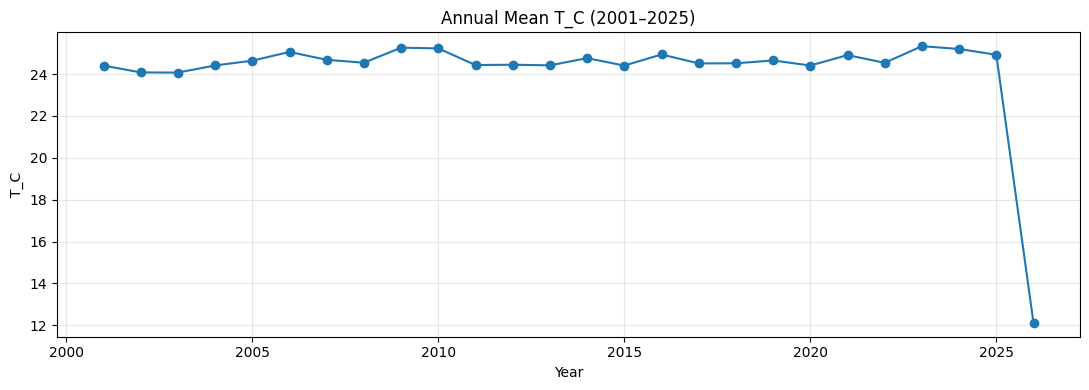

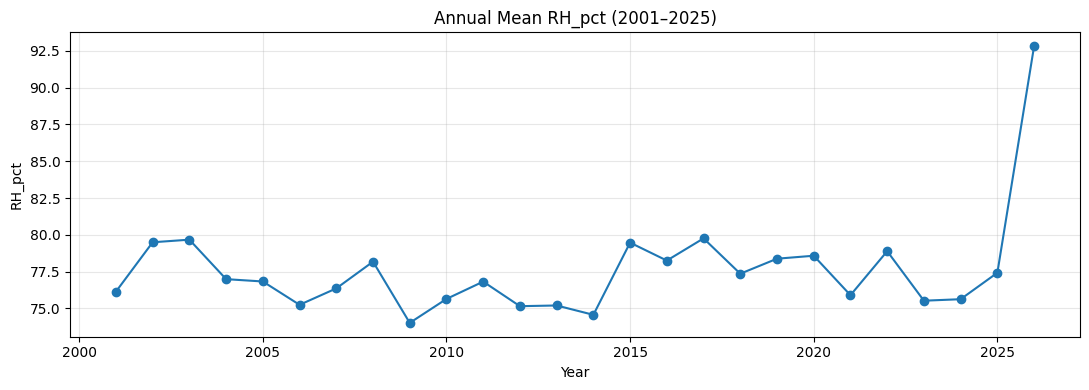

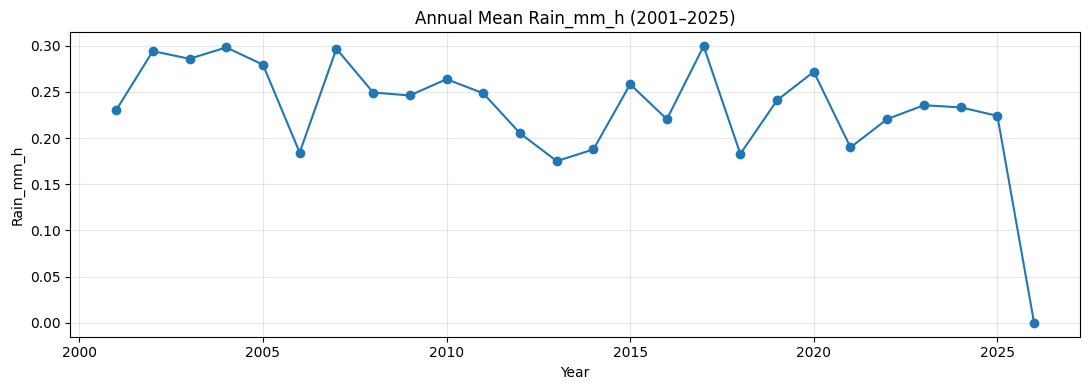

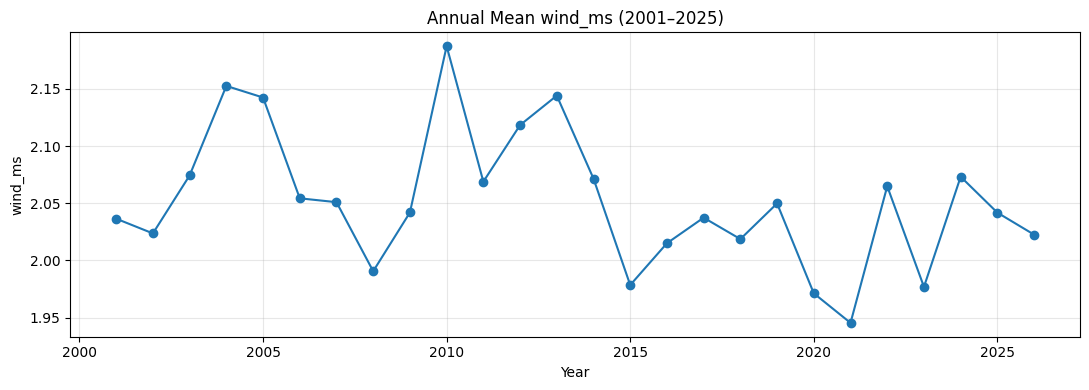


MONTHLY CLIMATOLOGY


,T_C,RH_pct,Rain_mm_h,wind_ms
month,,,,
1,17.629877,70.932325,0.013771,1.740757
2,20.568378,64.283743,0.027488,1.803877
3,24.764694,59.993230,0.053839,2.046747
4,26.790792,72.436973,0.197066,2.301678
5,27.317412,81.934265,0.450933,2.275611
6,27.936206,86.398556,0.557043,2.558365
7,27.974603,86.059713,0.497362,2.719913
8,27.936462,86.065451,0.431526,2.446075
9,27.547971,86.738626,0.389468,1.975147


T_C                                   RH_pct             \
            mean       std       min       max       mean        std   
month                                                                  
1      17.629877  4.253269   6.63506  27.94558  70.932325  16.415298   
2      20.568378  4.813017   7.98388  34.91738  64.283743  18.696244   
3      24.764694  4.833029  10.65994  39.07858  59.993230  21.067337   
4      26.790792  4.323461  16.12872  40.76290  72.436973  20.587353   
5      27.317412  3.374272  19.40188  40.50082  81.934265  13.848916   
6      27.936206  2.498113  22.67526  38.30966  86.398556   9.860461   
7      27.974603  2.088499  24.05880  35.86530  86.059713   9.120063   
8      27.936462  2.095126  23.98635  36.18667  86.065451   9.034292   
9      27.547971  2.310883  21.85494  36.57910  86.738626   9.406428   
10     25.808561  3.041267  16.89280  33.61126  83.283636  12.359522   
11     22.419574  3.998826  10.71290  32.14327  73.836753  15.802280   
12     19.144817  4.162544   8.89266  29.06307  71.528053  15.947157   

                             Rain_mm_h                             wind_ms  \
             min         max      mean       std  min        max      mean   
month                                                                        
1      29.384875   99.998243  0.013771  0.113039  0.0   3.536135  1.740757   
2      20.185214   99.726602  0.027488  0.225561  0.0   8.876101  1.803877   
3      12.466126   99.793154  0.053839  0.322361  0.0   8.842528  2.046747   
4       9.381617   99.568451  0.197066  0.749675  0.0  12.456417  2.301678   
5      11.530798   99.553656  0.450933  1.221705  0.0  34.421040  2.275611   
6      35.862444   99.564625  0.557043  1.227275  0.0  19.647524  2.558365   
7      55.381073   99.572336  0.497362  1.052460  0.0  18.659383  2.719913   
8      58.460965   99.565520  0.431526  0.951629  0.0  17.850507  2.446075   
9      49.982501   99.683540  0.389468  0.819485  0.0  13.373256  1.975147   
10     41.133631   99.949924  0.232037  0.981792  0.0  25.347471  1.543837   
11     31.168020  100.000000  0.019075  0.270503  0.0  13.506349  1.572223   
12     30.521793   99.986751  0.007103  0.080811  0.0   3.780454  1.638947   

                                      
            std       min        max  
month                                 
1      0.600424  0.014598   4.577172  
2      0.745099  0.013408   7.297514  
3      0.896462  0.027055   7.943556  
4      0.912983  0.034756   7.526542  
5      1.015570  0.020256  11.897181  
6      1.003555  0.048631   9.003886  
7      1.037873  0.018238   8.651426  
8      1.073055  0.012765   8.945628  
9      1.008230  0.003423   8.171313  
10     0.766467  0.009732   9.196257  
11     0.583910  0.014443   6.602953  
12     0.571598  0.005334   4.115094

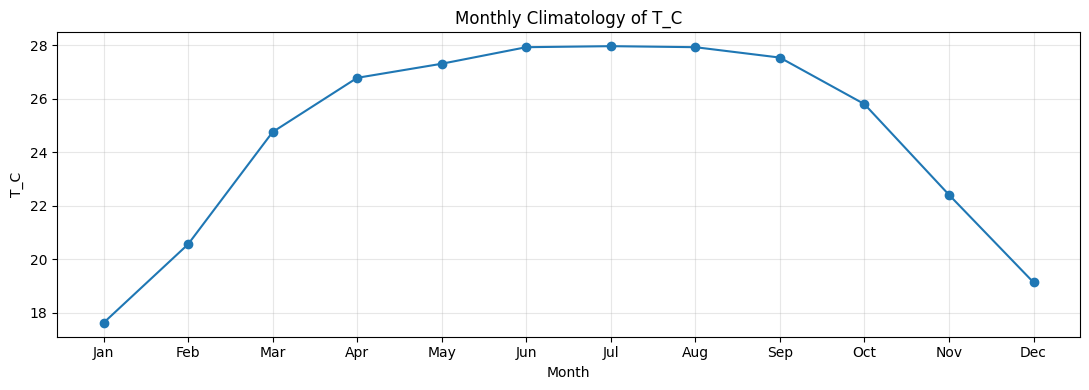

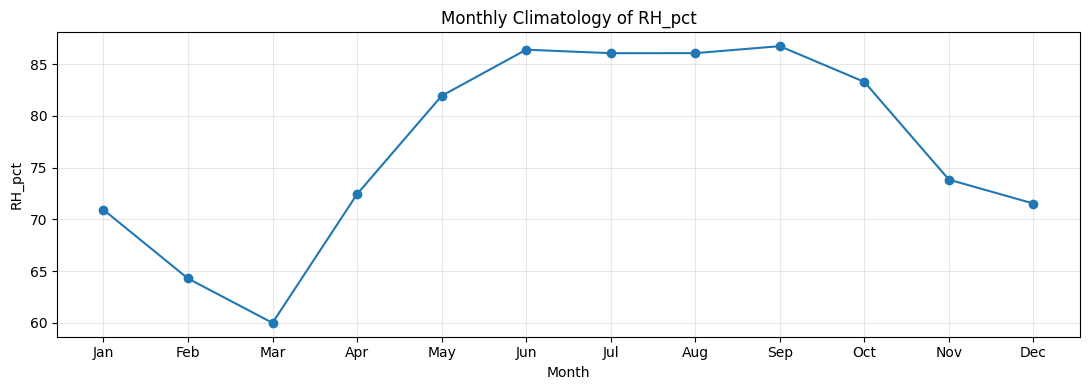

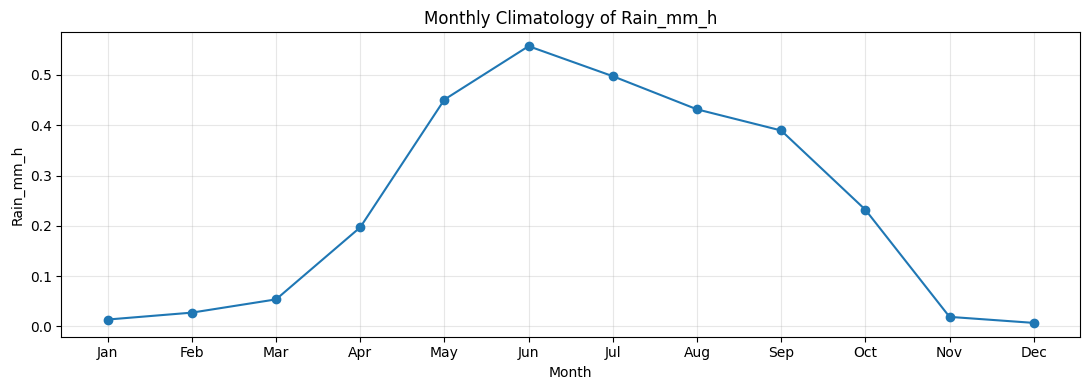

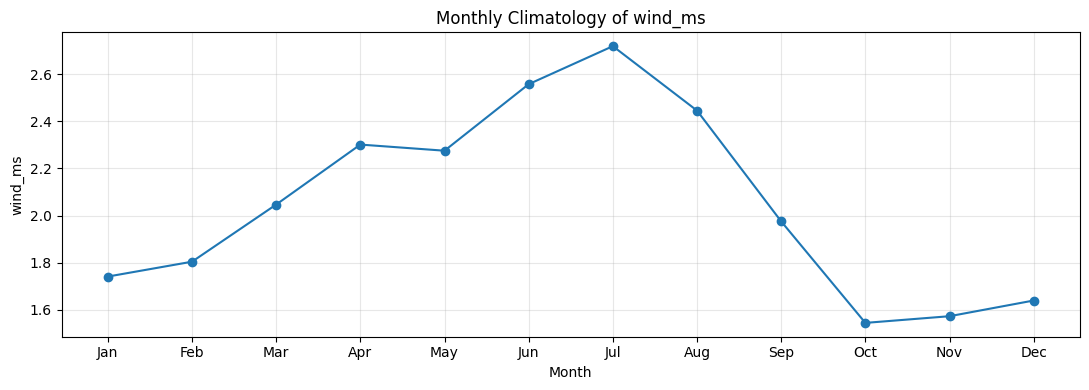


SEASONAL CLIMATOLOGY


,T_C,RH_pct,Rain_mm_h,wind_ms
season,,,,
Winter,19.069888,69.056391,0.015773,1.725534
Pre-monsoon,26.285533,71.444147,0.234347,2.206994
Monsoon,27.850559,86.311438,0.468776,2.427465
Post-monsoon,24.141846,78.637628,0.127301,1.557797



Seasonal standard deviation:


,T_C,RH_pct,Rain_mm_h,wind_ms
season,,,,
Winter,4.564249,17.313141,0.150412,0.643724
Pre-monsoon,4.361567,20.831683,0.865114,0.950401
Monsoon,2.258609,9.360270,1.025211,1.067807
Post-monsoon,3.928736,14.924483,0.732917,0.682950



24-HOUR DIURNAL CLIMATOLOGY


,T_C,RH_pct,Rain_mm_h,wind_ms
hour,,,,
0,22.430847,85.670752,0.264329,2.060773
1,22.232149,86.116046,0.254624,2.051113
2,21.899835,87.312707,0.288288,2.032973
3,21.580271,88.454715,0.311598,2.012124
4,21.294643,89.475223,0.308941,1.995773
5,21.047585,90.347479,0.288635,1.991838
6,20.877294,90.965957,0.260850,1.982128
7,21.192012,90.600305,0.234235,2.033612
8,22.728754,85.418119,0.211581,2.057608


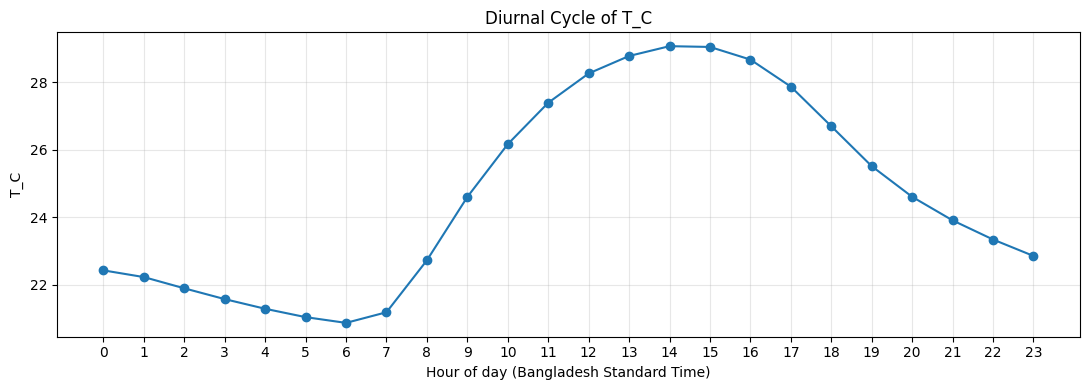

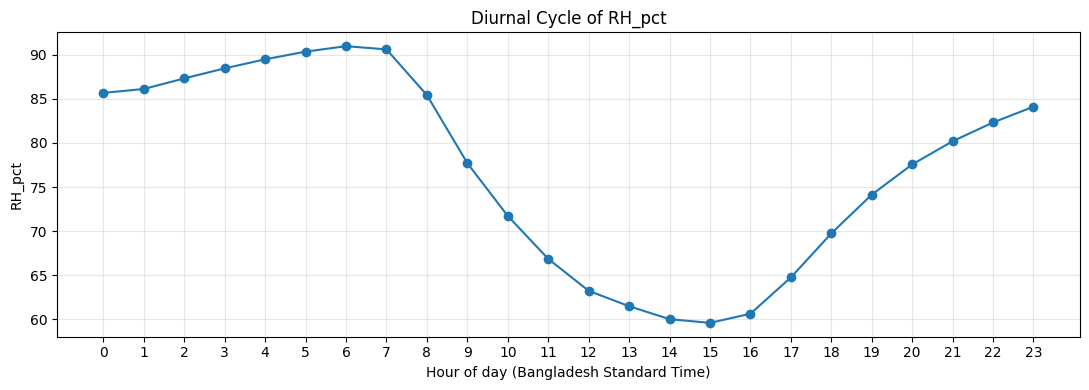

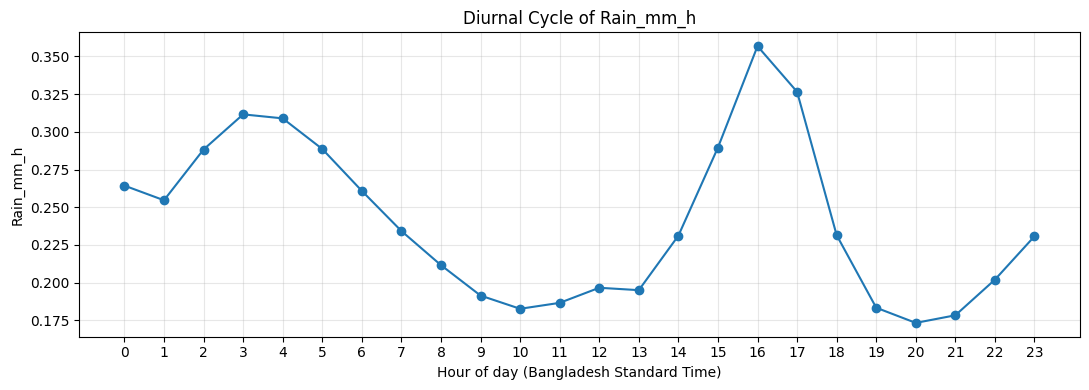

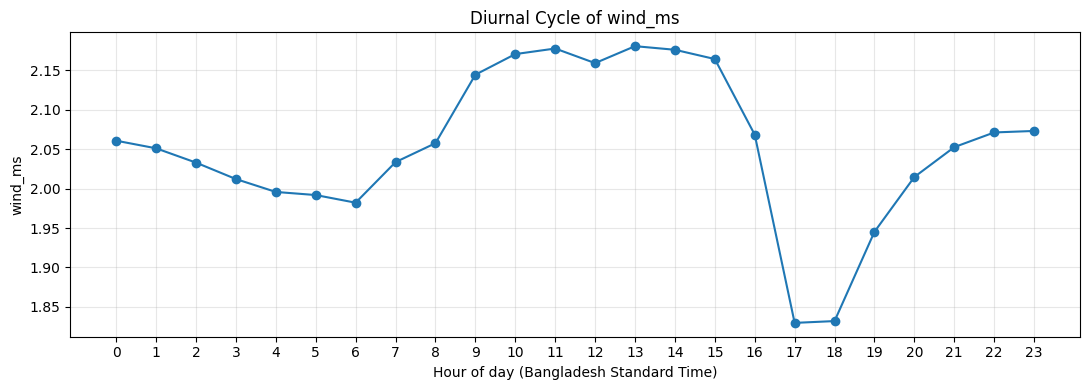


RAINFALL OCCURRENCE


,threshold_mm_h,hours,percentage_of_all_hours
0,0.00,219144,100.000000
1,0.01,87359,39.863743
2,0.10,53269,24.307761
3,0.50,24447,11.155678
4,1.00,14859,6.780473
5,2.50,4891,2.231866
6,5.00,1270,0.579528
7,10.00,174,0.079400



WET / DRY HOURS


,state,hours,percentage
0,Dry,99604,45.451393
1,Wet,119540,54.548607



RAINFALL INTENSITY WHEN RAIN OCCURS


,value
count,1.195400e+05
mean,4.413846e-01
std,1.064933e+00
min,5.684342e-11
25%,7.518749e-03
50%,7.193256e-02
75%,3.493438e-01
max,3.442104e+01


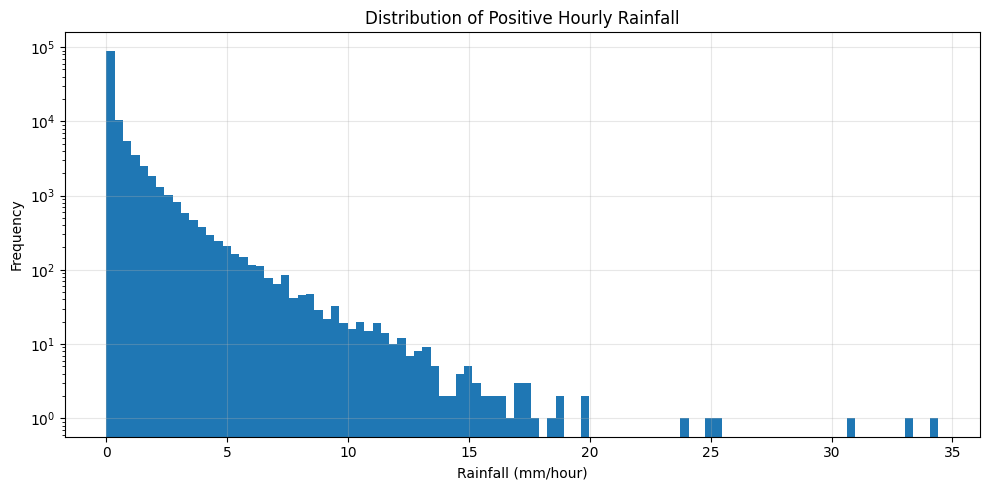


MONTHLY RAINFALL CLIMATOLOGY


,mean,sum,max
month,,,
1,0.013771,256.138821,3.536135
2,0.027488,465.753659,8.876101
3,0.053839,1001.396921,8.842528
4,0.197066,3547.186950,12.456417
5,0.450933,8387.356264,34.421040
6,0.557043,10026.217106,19.647524
7,0.497362,9250.927229,18.659383
8,0.431526,8026.377708,17.850507
9,0.389468,7010.425014,13.373256



PEARSON CORRELATION MATRIX


,T_C,RH_pct,Rain_mm_h,wind_ms
T_C,1.000000,-0.254405,0.074458,0.188943
RH_pct,-0.254405,1.000000,0.229940,0.060421
Rain_mm_h,0.074458,0.229940,1.000000,0.128559
wind_ms,0.188943,0.060421,0.128559,1.000000


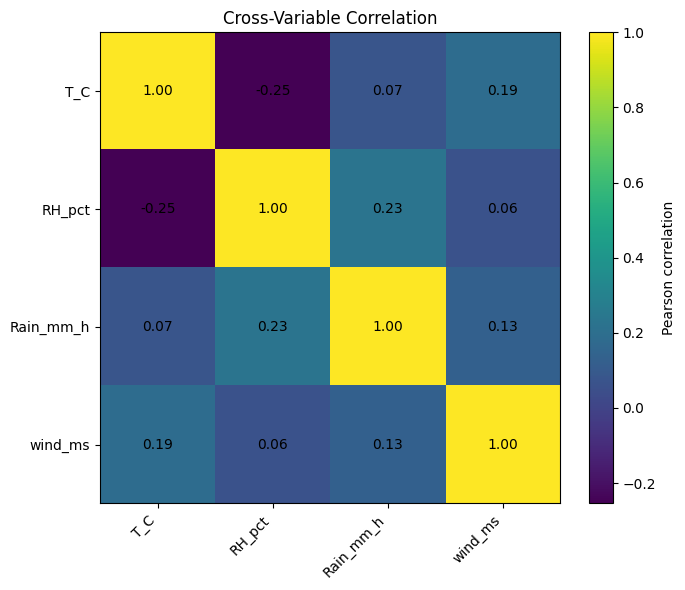


TEMPORAL AUTOCORRELATION


,variable,lag_hours,autocorrelation
0,T_C,1,0.979870
1,T_C,2,0.928752
2,T_C,3,0.856228
3,T_C,6,0.587196
4,T_C,12,0.278857
5,T_C,24,0.963460
6,T_C,48,0.938582
7,T_C,72,0.921382
8,T_C,120,0.900871
9,T_C,144,0.894427


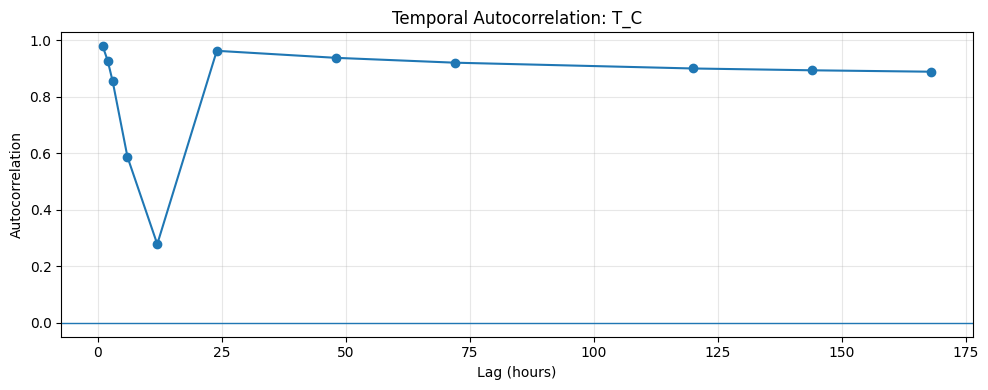

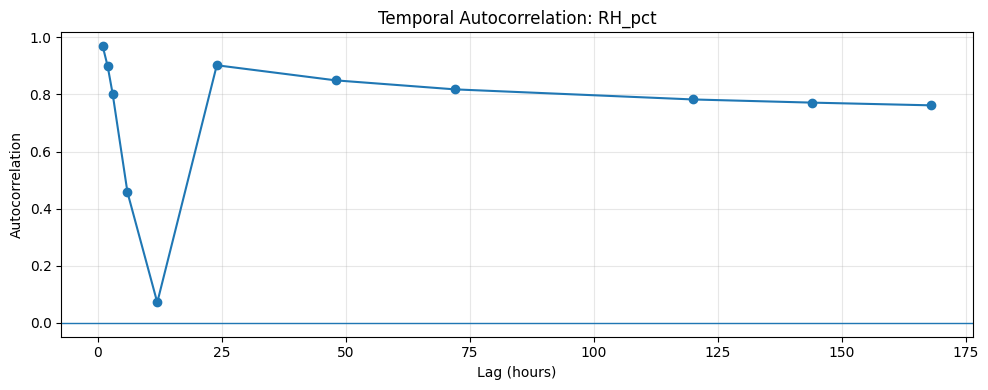

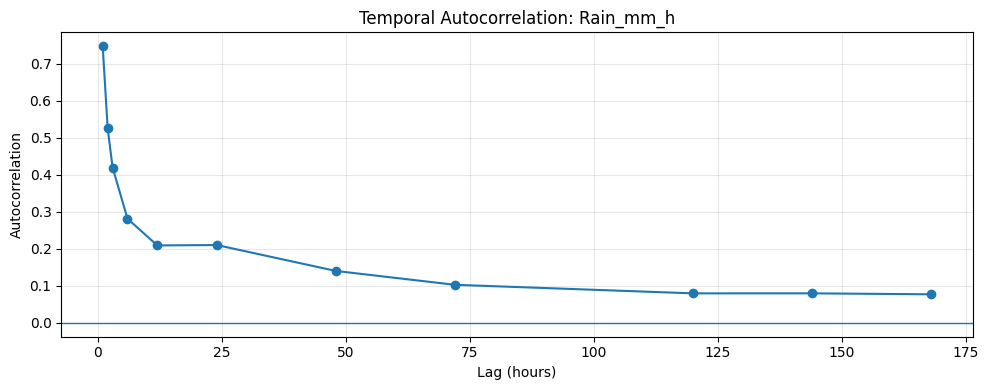

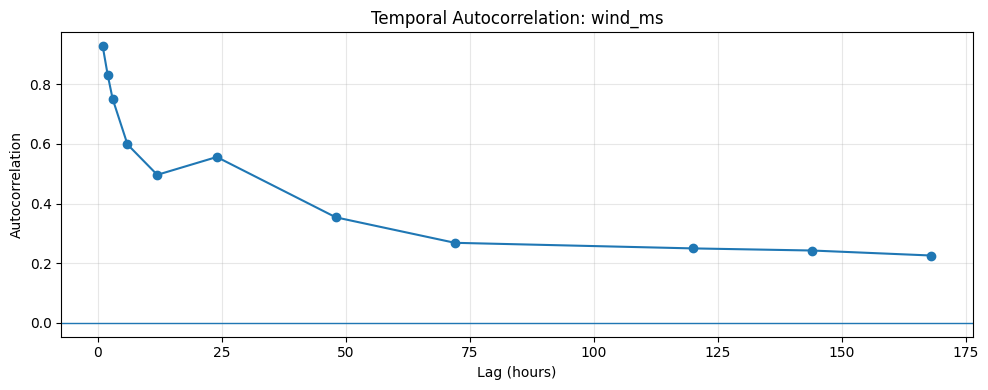


TOP 10 EXTREME VALUES: T_C


,datetime_utc,datetime_bst,T_C,RH_pct,Rain_mm_h,wind_ms
204489,2024-04-30 09:00:00+00:00,2024-04-30 15:00:00+06:00,40.76290,15.899022,0.000000,5.207378
204488,2024-04-30 08:00:00+00:00,2024-04-30 14:00:00+06:00,40.70150,17.032454,0.000000,4.768488
29504,2004-05-14 08:00:00+00:00,2004-05-14 14:00:00+06:00,40.50082,29.301794,0.002347,1.942038
204465,2024-04-29 09:00:00+00:00,2024-04-29 15:00:00+06:00,40.43896,15.181588,0.000000,5.708471
29432,2004-05-11 08:00:00+00:00,2004-05-11 14:00:00+06:00,40.43070,30.717856,0.005059,3.908536
29505,2004-05-14 09:00:00+00:00,2004-05-14 15:00:00+06:00,40.40620,27.928430,0.008412,1.137602
204464,2024-04-29 08:00:00+00:00,2024-04-29 14:00:00+06:00,40.26570,16.665652,0.000858,5.027919
29433,2004-05-11 09:00:00+00:00,2004-05-11 15:00:00+06:00,40.25594,26.137559,0.000760,3.339257
204393,2024-04-26 09:00:00+00:00,2024-04-26 15:00:00+06:00,40.24310,15.241279,0.000000,4.828121
204392,2024-04-26 08:00:00+00:00,2024-04-26 14:00:00+06:00,40.21505,15.922505,0.000000,4.683463



TOP 10 EXTREME VALUES: RH_pct


,datetime_utc,datetime_bst,T_C,RH_pct,Rain_mm_h,wind_ms
25008,2003-11-09 00:00:00+00:00,2003-11-09 06:00:00+06:00,16.67507,100.000000,0.000000,1.487141
18238,2003-01-30 22:00:00+00:00,2003-01-31 04:00:00+06:00,13.48940,99.998243,0.000000,1.260496
17256,2002-12-21 00:00:00+00:00,2002-12-21 06:00:00+06:00,14.40225,99.986751,0.000000,1.591963
7704,2001-11-18 00:00:00+00:00,2001-11-18 06:00:00+06:00,16.58870,99.953492,0.000000,1.277273
129816,2015-10-24 00:00:00+00:00,2015-10-24 06:00:00+06:00,20.48306,99.949924,0.000015,1.510442
18237,2003-01-30 21:00:00+00:00,2003-01-31 03:00:00+06:00,14.31698,99.942389,0.000000,1.129951
69673,2008-12-13 01:00:00+00:00,2008-12-13 07:00:00+06:00,15.83996,99.927670,0.000000,1.186833
211104,2025-01-31 00:00:00+00:00,2025-01-31 06:00:00+06:00,13.98315,99.925779,0.000000,1.431291
138359,2016-10-13 23:00:00+00:00,2016-10-14 05:00:00+06:00,21.55737,99.922873,0.000000,1.373862
18239,2003-01-30 23:00:00+00:00,2003-01-31 05:00:00+06:00,13.17703,99.913705,0.000671,1.138702



TOP 10 EXTREME VALUES: Rain_mm_h


,datetime_utc,datetime_bst,T_C,RH_pct,Rain_mm_h,wind_ms
12071,2002-05-18 23:00:00+00:00,2002-05-19 05:00:00+06:00,25.38015,91.411207,34.421040,4.636477
12070,2002-05-18 22:00:00+00:00,2002-05-19 04:00:00+06:00,25.34078,95.249462,33.369810,4.348873
143495,2017-05-15 23:00:00+00:00,2017-05-16 05:00:00+06:00,23.53613,97.543763,30.740082,1.743765
33012,2004-10-07 12:00:00+00:00,2004-10-07 18:00:00+06:00,22.83470,92.373341,25.347471,8.509666
143496,2017-05-16 00:00:00+00:00,2017-05-16 06:00:00+06:00,23.46218,97.027840,25.086700,3.116957
33013,2004-10-07 13:00:00+00:00,2004-10-07 19:00:00+06:00,23.07010,95.063105,24.039797,6.363069
143494,2017-05-15 22:00:00+00:00,2017-05-16 04:00:00+06:00,23.67830,96.922444,19.705713,1.924753
161658,2019-06-11 18:00:00+00:00,2019-06-12 00:00:00+06:00,27.21655,91.965577,19.647524,2.396535
22568,2003-07-30 08:00:00+00:00,2003-07-30 14:00:00+06:00,26.24154,96.268562,18.659383,3.909502
33014,2004-10-07 14:00:00+00:00,2004-10-07 20:00:00+06:00,23.17820,97.965541,18.649027,4.473632



TOP 10 EXTREME VALUES: wind_ms


,datetime_utc,datetime_bst,T_C,RH_pct,Rain_mm_h,wind_ms
73606,2009-05-25 22:00:00+00:00,2009-05-26 04:00:00+06:00,25.00040,93.859247,11.393905,11.897181
73604,2009-05-25 20:00:00+00:00,2009-05-26 02:00:00+06:00,24.80972,92.303894,8.554101,11.863513
73603,2009-05-25 19:00:00+00:00,2009-05-26 01:00:00+06:00,24.97787,90.454542,5.218387,11.684066
73605,2009-05-25 21:00:00+00:00,2009-05-26 03:00:00+06:00,24.88748,93.017919,10.527432,11.664640
73607,2009-05-25 23:00:00+00:00,2009-05-26 05:00:00+06:00,24.95450,93.949554,12.436688,11.254399
73609,2009-05-26 01:00:00+00:00,2009-05-26 07:00:00+06:00,24.59365,92.417712,6.321400,10.544745
73610,2009-05-26 02:00:00+00:00,2009-05-26 08:00:00+06:00,24.44000,92.087582,2.973746,10.291481
73608,2009-05-26 00:00:00+00:00,2009-05-26 06:00:00+06:00,24.88128,92.643435,11.003822,10.179783
73611,2009-05-26 03:00:00+00:00,2009-05-26 09:00:00+06:00,24.34225,91.648299,1.729384,9.708757
205141,2024-05-27 13:00:00+00:00,2024-05-27 19:00:00+06:00,26.44216,86.359762,5.266700,9.683394



EDA COMPLETED
EDA outputs saved to:
/content/drive/MyDrive/ERA5_Land_Gobindaganj_2001_2025_EDA


In [38]:
# ================================================================
# CELL 23–49 : COMPLETE EDA FOR ERA5-LAND 2001–2025
# ================================================================
# Purpose:
#   1. Dataset overview
#   2. Descriptive statistics
#   3. Distribution analysis
#   4. Monthly / seasonal / yearly patterns
#   5. Diurnal patterns
#   6. Rainfall occurrence and intensity
#   7. Cross-variable relationships
#   8. Temporal dependence / autocorrelation
#   9. Extreme-value inspection
#  10. Save EDA summaries to Google Drive
#
# NOTE:
#   - Raw data are NOT modified.
#   - No weather generator is fitted here.
#   - No LWD or PLB risk is calculated here.
# ================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------
# 23. Check processed dataset
# ------------------------------------------------

required_cols = [
    "datetime_utc",
    "datetime_bst",
    "latitude",
    "longitude",
    "T_C",
    "RH_pct",
    "Rain_mm_h",
    "wind_ms"
]

missing_cols = [c for c in required_cols if c not in processed_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("Processed dataset is ready.")
print("Shape:", processed_df.shape)


# ------------------------------------------------
# 24. Ensure datetime columns are proper datetime
# ------------------------------------------------

df = processed_df.copy()

df["datetime_utc"] = pd.to_datetime(
    df["datetime_utc"],
    utc=True
)

df["datetime_bst"] = pd.to_datetime(
    df["datetime_bst"],
    utc=True
).dt.tz_convert("Asia/Dhaka")

df = df.sort_values("datetime_utc").reset_index(drop=True)

print("\nDatetime conversion completed.")
print("Start:", df["datetime_utc"].min())
print("End  :", df["datetime_utc"].max())


# ------------------------------------------------
# 25. Basic dataset information
# ------------------------------------------------

print("\n" + "=" * 80)
print("BASIC DATASET INFORMATION")
print("=" * 80)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)


# ------------------------------------------------
# 26. Descriptive statistics
# ------------------------------------------------

variables = [
    "T_C",
    "RH_pct",
    "Rain_mm_h",
    "wind_ms"
]

desc_stats = df[variables].describe().T

desc_stats["median"] = df[variables].median()
desc_stats["skewness"] = df[variables].skew()
desc_stats["kurtosis"] = df[variables].kurtosis()

desc_stats = desc_stats[
    [
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "median",
        "50%",
        "75%",
        "max",
        "skewness",
        "kurtosis"
    ]
]

print("\n" + "=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)

display(desc_stats)


# ------------------------------------------------
# 27. Missing and duplicate check
# ------------------------------------------------

print("\n" + "=" * 80)
print("DATA QUALITY CHECK")
print("=" * 80)

print("Missing values:")
display(df[variables].isna().sum().to_frame("missing_count"))

print("Duplicate UTC timestamps:",
      df["datetime_utc"].duplicated().sum())

print("Unique latitude:",
      df["latitude"].nunique())

print("Unique longitude:",
      df["longitude"].nunique())


# ------------------------------------------------
# 28. Physical range summary
# ------------------------------------------------

print("\n" + "=" * 80)
print("PHYSICAL RANGE CHECK")
print("=" * 80)

range_table = pd.DataFrame({
    "min": df[variables].min(),
    "max": df[variables].max(),
    "mean": df[variables].mean()
})

display(range_table)


# ------------------------------------------------
# 29. Add temporal helper columns
# ------------------------------------------------

df["year"] = df["datetime_bst"].dt.year
df["month"] = df["datetime_bst"].dt.month
df["month_name"] = df["datetime_bst"].dt.strftime("%b")
df["day"] = df["datetime_bst"].dt.day
df["hour"] = df["datetime_bst"].dt.hour
df["day_of_year"] = df["datetime_bst"].dt.dayofyear
df["week"] = df["datetime_bst"].dt.isocalendar().week.astype(int)

# Meteorological seasons for Bangladesh context
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Pre-monsoon"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-monsoon"

df["season"] = df["month"].apply(get_season)

print("Temporal helper variables created.")


# ------------------------------------------------
# 30. Yearly statistics
# ------------------------------------------------

yearly_stats = df.groupby("year")[variables].agg(
    ["mean", "std", "min", "max"]
)

print("\n" + "=" * 80)
print("YEARLY STATISTICS")
print("=" * 80)

display(yearly_stats.head())
display(yearly_stats.tail())


# ------------------------------------------------
# 31. Annual mean plots
# ------------------------------------------------

annual_mean = df.groupby("year")[variables].mean()

for var in variables:

    plt.figure(figsize=(11, 4))

    plt.plot(
        annual_mean.index,
        annual_mean[var],
        marker="o"
    )

    plt.xlabel("Year")
    plt.ylabel(var)
    plt.title(f"Annual Mean {var} (2001–2025)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------
# 32. Monthly climatology
# ------------------------------------------------

monthly_mean = df.groupby("month")[variables].mean()

print("\n" + "=" * 80)
print("MONTHLY CLIMATOLOGY")
print("=" * 80)

display(monthly_mean)


# ------------------------------------------------
# 33. Monthly distribution / variability
# ------------------------------------------------

monthly_summary = df.groupby("month")[variables].agg(
    ["mean", "std", "min", "max"]
)

display(monthly_summary)


# ------------------------------------------------
# 34. Monthly climatology plots
# ------------------------------------------------

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

for var in variables:

    plt.figure(figsize=(11, 4))

    plt.plot(
        range(1, 13),
        monthly_mean[var],
        marker="o"
    )

    plt.xticks(
        range(1, 13),
        month_labels
    )

    plt.xlabel("Month")
    plt.ylabel(var)
    plt.title(f"Monthly Climatology of {var}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------
# 35. Seasonal climatology
# ------------------------------------------------

season_order = [
    "Winter",
    "Pre-monsoon",
    "Monsoon",
    "Post-monsoon"
]

seasonal_mean = (
    df.groupby("season")[variables]
    .mean()
    .reindex(season_order)
)

print("\n" + "=" * 80)
print("SEASONAL CLIMATOLOGY")
print("=" * 80)

display(seasonal_mean)


# ------------------------------------------------
# 36. Seasonal variability
# ------------------------------------------------

seasonal_std = (
    df.groupby("season")[variables]
    .std()
    .reindex(season_order)
)

print("\nSeasonal standard deviation:")
display(seasonal_std)


# ------------------------------------------------
# 37. Diurnal cycle
# ------------------------------------------------

hourly_mean = df.groupby("hour")[variables].mean()

print("\n" + "=" * 80)
print("24-HOUR DIURNAL CLIMATOLOGY")
print("=" * 80)

display(hourly_mean)


# ------------------------------------------------
# 38. Diurnal plots
# ------------------------------------------------

for var in variables:

    plt.figure(figsize=(11, 4))

    plt.plot(
        hourly_mean.index,
        hourly_mean[var],
        marker="o"
    )

    plt.xticks(range(0, 24))
    plt.xlabel("Hour of day (Bangladesh Standard Time)")
    plt.ylabel(var)
    plt.title(f"Diurnal Cycle of {var}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------
# 39. Rainfall occurrence analysis
# ------------------------------------------------

rain = df["Rain_mm_h"]

rain_thresholds = [
    0,
    0.01,
    0.10,
    0.50,
    1.00,
    2.50,
    5.00,
    10.00
]

rain_occurrence = []

for threshold in rain_thresholds:

    count = (rain >= threshold).sum()

    rain_occurrence.append({
        "threshold_mm_h": threshold,
        "hours": count,
        "percentage_of_all_hours": 100 * count / len(rain)
    })

rain_occurrence_df = pd.DataFrame(rain_occurrence)

print("\n" + "=" * 80)
print("RAINFALL OCCURRENCE")
print("=" * 80)

display(rain_occurrence_df)


# ------------------------------------------------
# 40. Wet / dry hours
# ------------------------------------------------

wet_mask = rain > 0

wet_hours = wet_mask.sum()
dry_hours = (~wet_mask).sum()

wet_summary = pd.DataFrame({
    "state": ["Dry", "Wet"],
    "hours": [dry_hours, wet_hours],
    "percentage": [
        100 * dry_hours / len(df),
        100 * wet_hours / len(df)
    ]
})

print("\n" + "=" * 80)
print("WET / DRY HOURS")
print("=" * 80)

display(wet_summary)


# ------------------------------------------------
# 41. Rainfall intensity conditional on rain
# ------------------------------------------------

wet_rain = rain[rain > 0]

rain_intensity_stats = wet_rain.describe()

print("\n" + "=" * 80)
print("RAINFALL INTENSITY WHEN RAIN OCCURS")
print("=" * 80)

display(rain_intensity_stats.to_frame("value"))


# ------------------------------------------------
# 42. Rainfall distribution
# ------------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(
    wet_rain,
    bins=100
)

plt.xlabel("Rainfall (mm/hour)")
plt.ylabel("Frequency")
plt.title("Distribution of Positive Hourly Rainfall")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------
# 43. Rainfall monthly climatology
# ------------------------------------------------

monthly_rain = df.groupby("month")["Rain_mm_h"].agg(
    ["mean", "sum", "max"]
)

print("\n" + "=" * 80)
print("MONTHLY RAINFALL CLIMATOLOGY")
print("=" * 80)

display(monthly_rain)


# ------------------------------------------------
# 44. Variable correlation matrix
# ------------------------------------------------

corr_matrix = df[variables].corr(method="pearson")

print("\n" + "=" * 80)
print("PEARSON CORRELATION MATRIX")
print("=" * 80)

display(corr_matrix)


# ------------------------------------------------
# 45. Correlation heatmap
# ------------------------------------------------

plt.figure(figsize=(7, 6))

plt.imshow(
    corr_matrix,
    interpolation="nearest",
    aspect="auto"
)

plt.colorbar(label="Pearson correlation")

plt.xticks(
    range(len(variables)),
    variables,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(variables)),
    variables
)

for i in range(len(variables)):
    for j in range(len(variables)):

        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Cross-Variable Correlation")
plt.tight_layout()
plt.show()


# ------------------------------------------------
# 46. Autocorrelation
# ------------------------------------------------

lags = [
    1, 2, 3, 6, 12,
    24, 48, 72, 120, 144, 168
]

acf_results = []

for var in variables:

    for lag in lags:

        value = df[var].autocorr(lag=lag)

        acf_results.append({
            "variable": var,
            "lag_hours": lag,
            "autocorrelation": value
        })

acf_df = pd.DataFrame(acf_results)

print("\n" + "=" * 80)
print("TEMPORAL AUTOCORRELATION")
print("=" * 80)

display(acf_df)


# ------------------------------------------------
# 47. Autocorrelation plots
# ------------------------------------------------

for var in variables:

    subset = acf_df[
        acf_df["variable"] == var
    ]

    plt.figure(figsize=(10, 4))

    plt.plot(
        subset["lag_hours"],
        subset["autocorrelation"],
        marker="o"
    )

    plt.axhline(
        0,
        linewidth=1
    )

    plt.xlabel("Lag (hours)")
    plt.ylabel("Autocorrelation")
    plt.title(f"Temporal Autocorrelation: {var}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------
# 48. Extreme-value inspection
# ------------------------------------------------

extreme_tables = {}

for var in variables:

    top_values = (
        df.nlargest(10, var)
        [
            [
                "datetime_utc",
                "datetime_bst",
                "T_C",
                "RH_pct",
                "Rain_mm_h",
                "wind_ms"
            ]
        ]
    )

    extreme_tables[var] = top_values

    print("\n" + "=" * 80)
    print(f"TOP 10 EXTREME VALUES: {var}")
    print("=" * 80)

    display(top_values)


# ------------------------------------------------
# 49. Save all important EDA outputs
# ------------------------------------------------

EDA_DIR = "/content/drive/MyDrive/ERA5_Land_Gobindaganj_2001_2025_EDA"

os.makedirs(EDA_DIR, exist_ok=True)

# Save tables
desc_stats.to_csv(
    f"{EDA_DIR}/descriptive_statistics.csv"
)

annual_mean.to_csv(
    f"{EDA_DIR}/annual_mean.csv"
)

monthly_mean.to_csv(
    f"{EDA_DIR}/monthly_mean.csv"
)

seasonal_mean.to_csv(
    f"{EDA_DIR}/seasonal_mean.csv"
)

seasonal_std.to_csv(
    f"{EDA_DIR}/seasonal_std.csv"
)

hourly_mean.to_csv(
    f"{EDA_DIR}/diurnal_mean.csv"
)

rain_occurrence_df.to_csv(
    f"{EDA_DIR}/rainfall_occurrence.csv",
    index=False
)

wet_summary.to_csv(
    f"{EDA_DIR}/wet_dry_hours.csv",
    index=False
)

monthly_rain.to_csv(
    f"{EDA_DIR}/monthly_rainfall.csv"
)

corr_matrix.to_csv(
    f"{EDA_DIR}/correlation_matrix.csv"
)

acf_df.to_csv(
    f"{EDA_DIR}/autocorrelation.csv",
    index=False
)

# Save extreme-value tables
for var, table in extreme_tables.items():

    safe_name = (
        var
        .replace("/", "_")
        .replace(" ", "_")
    )

    table.to_csv(
        f"{EDA_DIR}/extremes_{safe_name}.csv",
        index=False
    )

print("\n" + "=" * 80)
print("EDA COMPLETED")
print("=" * 80)

print("EDA outputs saved to:")
print(EDA_DIR)